In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
sllm = ChatOpenAI(model='gpt-4o-mini')

In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str                    
    context: list
    answer: str                    
    
graph_builder = StateGraph(AgentState)

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['income_tax', 'real_estate_tax', 'llm'] = Field(
        description="The target for the query to answer"
    )
    
router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'real_estate_tax', or 'llm'.
'income_tax' contains information about income tax up to December 2024.
'real_estate_tax' contains information about real estate tax up to December 2024.
if you think the question is not related to either 'income_tax' or 'real_estate_tax', you can route it to 'llm'.
"""

router_prompt = ChatPromptTemplate.from_messages([ 
    ("system", router_system_prompt),
    ("user", '{query}'),
])

structured_router_llm = sllm.with_structured_output(Route)

def router(state: AgentState):
    query = state['query']
    router_chain = router_prompt | structured_router_llm 
    route = router_chain.invoke({'query' : query})
    print(f'router route == {route}')
    print(f'router target == {route.target}')
    return route.target

In [7]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState):
    query = state['query']
    llm_chain = sllm | StrOutputParser()
    llm_answer = llm_chain.invoke({'query' : query})    
    return {'answer' : llm_answer}

In [8]:
from income_tax_graph import graph as income_tax_agent
from real_estate_tax_graph import graph as real_estate_tax_agent

graph_builder.add_node('llm', call_llm)
graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_estate_tax_agent)

In [9]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START, 
    router, 
    {
        'income_tax' : 'income_tax',
        'real_estate_tax' : 'real_estate_tax',
        'llm' : 'llm'
    })
graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)

In [10]:
graph = graph_builder.compile()

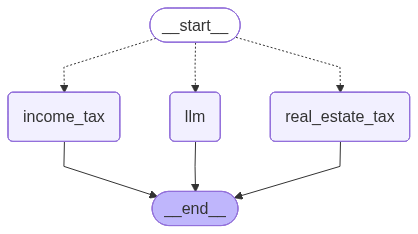

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
initial_state = {'query' : "소득세랑 무엇인가요?"}
graph.invoke(initial_state)

router route == target='income_tax'
router target == income_tax


{'query': '소득세랑 무엇인가요?',
 'context': [Document(id='5273b38b-845a-432a-af10-8268e31fa90c', metadata={'source': './Documents/income_tax.txt'}, page_content='①조 세특례제한법, 또는 이 법 제12조에 따른 과세제외 소득  \n대통령령으로 정하는 임금소득(이하 “임금소득”이라 한다)과 근로소득  \n\n제12조제2항의 세호에 따라 원천징수하는 이자소득 및 배당소득과 제16조제1항제10호에 따른 직장공제회초 관련소득  \n\n\n법인으로 보는 단체 외의 단체 중 소득을 구성함에 배분하지 아니하는 단체로서 단체를 표기하는 금융거래를 하는 단체가 “금융신용기관” 및 비임금소득에 관한 법령이 제20조제1항 목의 이후에 해당하는 금융사업을 하는 단체(이하 “금융회사”等이란)로부터 받은 이자소득 및 배당소득  \n\n\n①조 세특례제한법에 따른 보통계소득  \n\n\n제30조부터 제35조까지의 규정 외의 이자소득과 배당소득(제17조제1항제8호에 따른 배당소득을 제외한다)으로서 그 소득의 합계액이 2천만원(이하 “이자소득의 종합세액기준금액”이라 한다) 이하인 경우 제17조에 따른 원천징수된 소득  \n\n\n해당 과세기간에 배당행정을 정하는 총수입금액의 합계액이 2천만원 이하인 자의 주택임대소득(이하 “분리과세 주택임대소득”이라 한다). 이 경우 주택임대소득이 산정 등에 필요한 대책행령으로 정한다.  \n\n\n다음 각 목 외의 기타소득(이하 “분리과세 기타소득”이라 한다)  \n\n\n가. 제21조제1항제3호 제4항, 제19조, 제20조제1항, 제22조제2항, 제26조 및 제26조의2 및 제 127조에 따라 원천징수(제21조제19항에 의하여 원천징수되지 아니하는 경우를 포함한다) 소득. 다만, 해당 소득이 있는 거주자가 종합소득과세표준을 계산해 고소득을 합산하는 경우 그 소득은 분리과세로 세액계산에 제외한다.  \n나. 제21조제19항제2조 및 같은 조 

In [14]:
initial_state = {'query' : "집 15억은 세금을 얼마나 내나요?"}
graph.invoke(initial_state)

router route == target='real_estate_tax'
router target == real_estate_tax


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-XoeBSRsnt4s24liNt6pe57W7 on tokens per min (TPM): Limit 30000, Used 30000, Requested 2228. Please try again in 4.456s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

In [16]:
initial_state = {'query' : "떡볶이는 어디가 맛있나요?"}
graph.invoke(initial_state)

router route == target='llm'
router target == llm


ValueError: Invalid input type <class 'dict'>. Must be a PromptValue, str, or list of BaseMessages.